# Lab 09: Multi-Perspective Customer Segmentation

**Learning Objectives:**
1. Organize features into business-driven perspectives
2. Apply optimal K selection separately to perspectives
3. **Merge perspectives using HC on centroids**
4. Profile and characterize merged segments
5. Interpret feature importance via R² decomposition
6. Translate clusters into business personas

In [1]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.base import clone
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import dendrogram
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Set plotting style
sns.set()
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Cell 4: Load preprocessed data
df = pd.read_csv('../data/data_preprocessed.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (8817, 35)


,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,...,oh_status_Widow,oh_gender_M,oh_dependents_1.0,oh_description_Kind of OK,oh_description_Meh...,oh_description_OK nice!,oh_description_Take my money!!,PC0,PC1,PC2
0,78,0.743162,1.191605,0.457819,1402,-0.617023,-0.243065,1.216847,0.495837,-0.499274,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.896356,-1.937697,1.120781
1,88,1.559488,1.100011,-1.535723,1537,0.166160,-0.790228,0.740464,-0.374374,-0.631907,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.981092,-1.421498,0.785625
2,34,-1.548542,-0.823463,0.557496,44,-0.834573,1.672006,-0.371096,-0.809480,2.286023,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,-2.813108,0.381440,-0.780867
3,69,0.845528,0.550447,-1.402820,888,0.383710,0.440889,-0.768082,-0.084304,-0.234007,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.247013,-0.514177,-1.302203
4,69,0.782435,1.008417,-0.871209,1138,0.340200,-0.243065,-0.053508,-0.374374,-0.366640,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.781920,-0.704805,-0.443376


In [3]:
# Splitting feature names into groups
# Remember which metric_features we decided to keep?
metric_features = ['income',
 'frq',
 'rcn',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase',
 'spent_online']

non_metric_features = df.columns[df.columns.str.startswith('oh_')].tolist() 

unused_features = [i for i in df.columns if i not in (metric_features+non_metric_features) ]

print("Metric features:", metric_features)
print("Non-metric features:", non_metric_features)
print("Unused features:", unused_features)

Metric features: ['income', 'frq', 'rcn', 'clothes', 'kitchen', 'small_appliances', 'toys', 'house_keeping', 'per_net_purchase', 'spent_online']
Non-metric features: ['oh_education_2nd Cycle', 'oh_education_Graduation', 'oh_education_Master', 'oh_education_PhD', 'oh_status_Married', 'oh_status_Single', 'oh_status_Together', 'oh_status_Widow', 'oh_gender_M', 'oh_dependents_1.0', 'oh_description_Kind of OK', 'oh_description_Meh...', 'oh_description_OK nice!', 'oh_description_Take my money!!']
Unused features: ['age', 'mnt', 'dependents', 'gender', 'education', 'status', 'description', 'birth_year', 'PC0', 'PC1', 'PC2']


# Before we proceed

- Preprocessing steps already done:
    - Dealt with inconsistencies (duplicates, dataypes)
    - Scaling
    - Univariate outlier removal
    - Dropped redudant features (`age`) 

- Important extra-steps:
    - Consider dropping/transforming the variable `rcn`. Why?
    - Multivariate outlier removal   

In [4]:
metric_features.remove('rcn')  # Removing 'rcn' as discussed previously

In [5]:
# Cell 7: Remove outliers using DBSCAN (vai falar melhor na proxima aula)
# Based on the hyperparameters that will be found in lab10
dbscan = DBSCAN(eps=1.9, min_samples=20, n_jobs=4)
dbscan_labels = dbscan.fit_predict(df[metric_features])

# Check outlier count
outlier_count = Counter(dbscan_labels)
print(f"DBSCAN results: {outlier_count}")
print(f"Outliers detected: {outlier_count[-1]}")
print(f"Core customers: {outlier_count[0]}")

# Save outliers for later classification
df_out = df[dbscan_labels == -1].copy()

##estamos a guarda los para mais tarde e nao os estamos a remover já pq estes outliers podem ser um cluster interessante para analisar depois. 
##(sao os milionarios- seria interessante analisar estes clientes)

##podemos tb guardar estes outliers para no fim de tudo inseri los no nosso modelo e perceber de que forma afetam o nosso modelo. 
##ou então no fim de tudo podemos tentar perceber onde faria sentido inserir estes outliers (podemos tb criar um modelo que percebea onde cada outlier se encaixa melhor)




# Filter to core customers only
df = df[dbscan_labels != -1].copy()
print(f"\nWorking with {len(df):,} core customers")
print(f"Outliers saved for later: {len(df_out)}")

DBSCAN results: Counter({np.int64(0): 8792, np.int64(-1): 25})
Outliers detected: 25
Core customers: 8792

Working with 8,792 core customers
Outliers saved for later: 25


# Defining the perspectives

- **Multi-Perspective Segmentation:** Different stakeholders need different analytical views
    - **Marketing Team** wants behavioral segments (how customers shop)
    - **Product Team** wants preference segments (what customers buy)
    - **Executive Team** wants ONE unified segmentation strategy


In [6]:
#vamos definir estas perspetivas com o nosso conhecimento e senso comum. Isto para a 2ª entrega do projeto

In [7]:
# Cell 5: Define feature perspectives

##este ponto é importante para percebermos como é que vamos segmentar os nossos clientes.
##tb é importante pq podemos perceber se algumas features dominam as outras. por exemplo, se há pessoas com alto income que compram muita roupa nós nao conseguimos perceber pq o income domina sobre o label ?(nao tenho a certeza se é isso)

# Behavioral features (how customers shop)
demographic_features = [
    'income',
    'frq',
    'per_net_purchase',
    'spent_online'
]

# Product Preference features (what customers buy)
preference_features = [
    'clothes',
    'kitchen',
    'small_appliances',
    'toys',
    'house_keeping'
]

# Combined metric features (for final analysis)
metric_features = demographic_features + preference_features

print("Demographic features:", demographic_features)
print("Product Preference features:", preference_features)
print("Total metric features:", len(metric_features))

Demographic features: ['income', 'frq', 'per_net_purchase', 'spent_online']
Product Preference features: ['clothes', 'kitchen', 'small_appliances', 'toys', 'house_keeping']
Total metric features: 9


# Clustering for each perspective 

##### For each clustering perspective we need to define 

- Clustering algorithm 
- Number of clusters 

## Demographic perspective

In [8]:
# se escolhermos k-means para a demographic perpspective, nao temos de usar o mesmo cluster algorithm para a preference perspective
# no fim de tudo vamos fazer merge com as duas perspetivas mas agora eles são indpendentes e podemos trabalhar com eles de forma diferente, tanto a nivel de algortimos como numero de clusters

In [9]:
df_dem = df[demographic_features].copy()
df_dem

,income,frq,per_net_purchase,spent_online
0,0.743162,1.191605,-1.257560,0.522055
1,1.559488,1.100011,-1.798649,-0.237578
2,-1.548542,-0.823463,0.906799,-0.904191
3,0.845528,0.550447,-0.391816,0.785568
4,0.782435,1.008417,-0.445925,1.237135
...,...,...,...,...
8812,0.618993,0.458853,0.257492,1.275517
8813,0.874744,0.733635,0.690363,1.865248
8814,-0.455617,-0.731869,1.556107,-0.801266
8815,-0.596155,0.825229,-0.608252,0.801051


In [10]:
kmeans = KMeans(
    init='k-means++',
    n_init=20,
    random_state=42
)


In [11]:
hierarchical = AgglomerativeClustering(
    metric='euclidean'
)

In [12]:
# Cell 3: Helper functions from Labs 09-12

def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.
    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.
    
    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    return ss


def get_ssb(df, feats, label_col):
    """
    Calculate the between-group sum of squares (SSB) for the given DataFrame.
    The between-group sum of squares is computed as the sum of the squared differences
    between the mean of each group and the overall mean, weighted by the number of observations
    in each group.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column in the DataFrame that contains the group labels.
    
    Returns:
    float: The between-group sum of squares of the DataFrame.
    """
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))))
    
    ssb = np.sum(ssb_i)
    return ssb


def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.
    
    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats + [label_col]
    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats),
        include_groups=False
    )
    return df_k.sum()


def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.
    
    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """
    df_sst_ = get_ss(df, feats)  # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)  # get ss within
    df_ssb_ = df_sst_ - df_ssw_  # get ss between
    # r2 = ssb/sst
    return (df_ssb_ / df_sst_)


def get_r2_scores(df, feats, clusterer, min_k=1, max_k=9):
    """
    Loop over different values of k. To be used with sklearn clusterers.
    """
    r2_clust = {}
    for n in range(min_k, max_k):
        clust = clone(clusterer).set_params(n_clusters=n)
        labels = clust.fit_predict(df)
        df_concat = pd.concat([df,
                               pd.Series(labels, name='labels', index=df.index)], axis=1)
        r2_clust[n] = get_rsq(df_concat, feats, 'labels')
    return r2_clust

In [13]:
r2_scores = {}

r2_scores['kmeans'] = get_r2_scores(df_dem, demographic_features, kmeans)

for linkage in ['complete', 'average', 'single', 'ward']:
    r2_scores[linkage] = get_r2_scores(
        df_dem,                 # data
        demographic_features,   # features of perspective
        # use HClust, changing the linkage at each iteration
        hierarchical.set_params(linkage=linkage) 
    )


In [14]:
r2_scores_df = pd.DataFrame(r2_scores)
r2_scores_df

,kmeans,complete,average,single,ward
1,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.571684,0.476406,0.068414,0.001028,0.550334
3,0.679349,0.527070,0.583720,0.001682,0.638016
4,0.756784,0.668176,0.585884,0.002605,0.712994
5,0.789384,0.708727,0.664679,0.003780,0.753292
6,0.819565,0.757008,0.665216,0.004541,0.781625
7,0.839166,0.770829,0.755694,0.004951,0.808584
8,0.854622,0.773782,0.757069,0.005151,0.828779


In [15]:
## Nao escolhemos a olhar para aqui, mas sim a olhar para o elbow plot, o grafico abaixo

#aqui só usamos algortimos dados até esta aula mas vai haver outrois que podemos usar como o que damos na aula seguinte

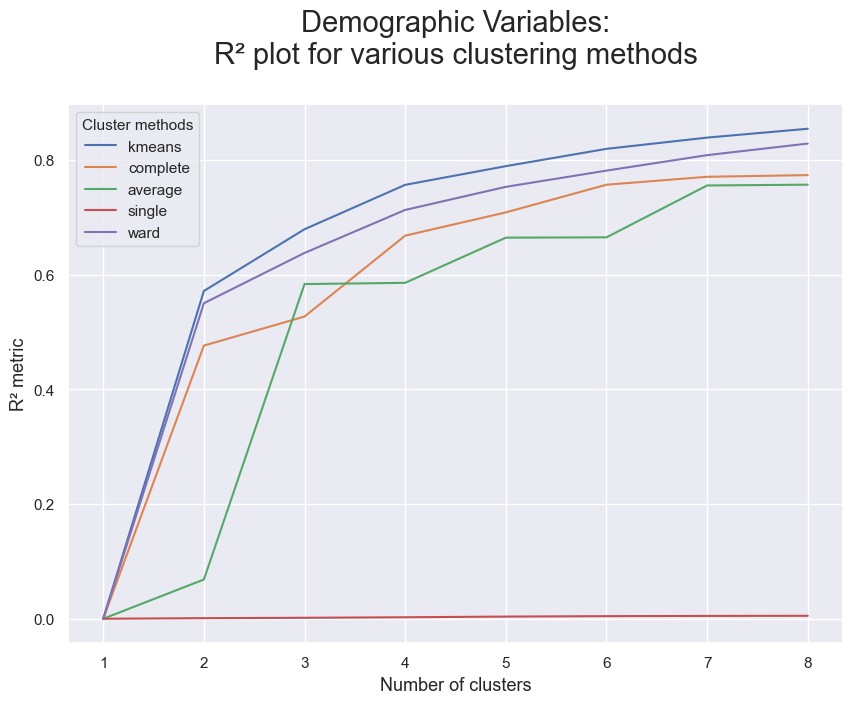

In [16]:
# Visualizing the R² scores for each cluster solution on demographic variables
r2_scores_df.plot.line(figsize=(10,7))

plt.title("Demographic Variables:\nR² plot for various clustering methods\n", fontsize=21)
plt.legend(title="Cluster methods", title_fontsize=11)
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R² metric", fontsize=13)
plt.show()

In [17]:
## nos queremos o k-means, pq é o que tem maiores valores de R^2, ou seja, a linha azul do gráfico. Aqui percebemos que devemos considerar 4 clusters

# se alinha azul fosse continua podiamos argumentar que o melhor numero de clusters seria 2

In [18]:
!!!!!!     A PARTIR DAQUI FIZEMOS NA AULA.    !!!!!!

['zsh:1: command not found: !!!!']

## Preferences / product perspective

In [19]:
# ===========================================================
# TODO IN CLASS EXERCISE
# Apply the same procedure to the preference features
# ===========================================================

df_prf = df[preference_features].copy()
df_prf

,clothes,kitchen,small_appliances,toys,house_keeping
0,-0.617023,-0.243065,1.216847,0.495837,-0.499274
1,0.166160,-0.790228,0.740464,-0.374374,-0.631907
2,-0.834573,1.672006,-0.371096,-0.809480,2.286023
3,0.383710,0.440889,-0.768082,-0.084304,-0.234007
4,0.340200,-0.243065,-0.053508,-0.374374,-0.366640
...,...,...,...,...,...
8812,0.209670,0.167308,-0.132905,0.205767,-0.764540
8813,0.731791,-0.243065,-0.609288,-0.519409,-0.366640
8814,0.079139,-0.106274,-0.053508,0.060732,-0.101374
8815,-0.442982,0.577680,0.581670,-0.809480,0.561792


In [20]:
r2_scores_pref = {}

r2_scores_pref['kmeans'] = get_r2_scores(df_prf, preference_features, kmeans)

for linkage in ['complete', 'average', 'single', 'ward']:
    r2_scores_pref[linkage] = get_r2_scores(
        df_prf,                 # data
        preference_features,    # features of perspective
        # use HClust, changing the linkage at each iteration
        hierarchical.set_params(linkage=linkage) 
    )

r2_scores_pref_df = pd.DataFrame(r2_scores_pref)
r2_scores_pref_df

,kmeans,complete,average,single,ward
1,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.396162,0.092334,0.065912,0.000548,0.295164
3,0.555338,0.306500,0.066303,0.000897,0.486133
4,0.610887,0.334692,0.075557,0.002591,0.562430
5,0.659963,0.349389,0.345555,0.003396,0.605805
6,0.693961,0.545847,0.366632,0.003637,0.641875
7,0.719603,0.558302,0.405431,0.004642,0.675509
8,0.739354,0.575572,0.425012,0.005027,0.702248


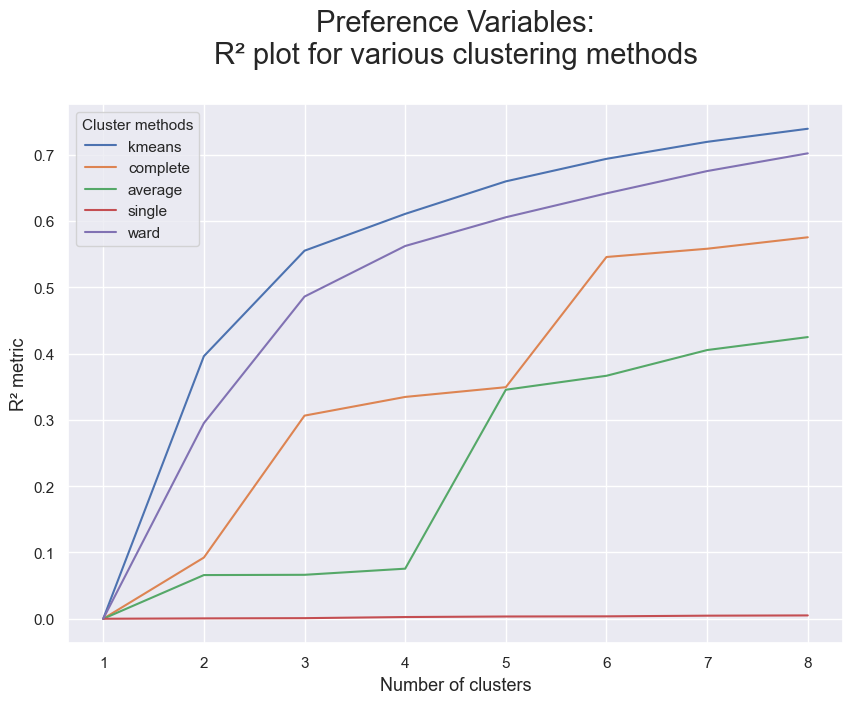

In [21]:
# Visualizing the R² scores for each cluster solution on  preference variables
r2_scores_pref_df.plot.line(figsize=(10,7))

plt.title("Preference Variables:\nR² plot for various clustering methods\n", fontsize=21)
plt.legend(title="Cluster methods", title_fontsize=11)
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R² metric", fontsize=13)
plt.show()

In [22]:
## Aqui percebemos que o melhor numero de clusters é 3, novamente com o k-means

## podiamos experimentar na mesma com 4 clusters, mas olhando para o gráfico o ponto cotovelo está nos 3 clusters e esta é a conclusão que devemos retirar do gráfico
##90% das vezes k-means é melhor que o hierarchical clustering

# Final solutions 

In [23]:
# ===========================================================
# TODO IN CLASS EXERCISE
# Apply the final clustering solution to the demographic features
# ===========================================================

kmeans_demo = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=20,
    random_state=42
)

demo_labels = kmeans_demo.fit_predict(df_dem)
#aqui nao fazemos df_dem (metric features) pq já estamos a usar um subset que só contem metric features
demo_labels

array([1, 1, 0, ..., 0, 3, 2], dtype=int32)

In [24]:
df['demographic_cluster'] = demo_labels

In [25]:
# ===========================================================
# TODO IN CLASS EXERCISE
# Apply the final clustering solution to the preference features    
# ===========================================================

kmeans_pref = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=20,
    random_state=42
)

pref_labels = kmeans_pref.fit_predict(df_prf)
pref_labels

array([0, 0, 2, ..., 0, 0, 1], dtype=int32)

In [26]:
df['product_cluster'] = pref_labels

In [27]:
print("Clustering complete!")
print(f"Behavioral clusters: {df['demographic_cluster'].nunique()}")
print(f"Preference clusters: {df['product_cluster'].nunique()}")

#agora vemos que temos 4 clusters na demographic perspective e 3 clusters na preference perspective

Clustering complete!
Behavioral clusters: 4
Preference clusters: 3


#### How many combinations of clusters we would have ? 

In [28]:
## temos então 12 combinações possiveis e estas 12 combinações vao ser os nosso clusters possiveis

In [29]:
crosstab = pd.crosstab(df['demographic_cluster'], df['product_cluster'])
crosstab

product_cluster,0,1,2
demographic_cluster,,,
0,1478,1157,1022
1,1255,386,285
2,255,709,47
3,653,1335,210


#### Are these 12 clusters balanced ? 

In [30]:
##Nao sao balanced pq vemos que há clusters com quase 1500 clientes e outros com menos de 100 clientes

#neste caso nenhuma loja iria qeurer gastar dinhiero num conjunto de clientes tao pequeno
##podemos pensar em juntar alguns clusters mais pequenos 

#### Are we finished ? 

. 

. 

. 

.


In [31]:
#depois de ter as soluções para as diferentes perspetivas, podemos fazer merge desses clusters, dessas soluções

# Merge clusters

#### Apply Hierarchical Clustering on cluster centroids

In [32]:
#em vez de fazer para todas as obsrrvações fazemo lo apenas para os centroides dos nossos clusters

In [33]:
# Cell 16: Calculate centroids for each combination
#Calculamos o centroide para cada um dos 12 grupos e vamos fazer hierarchical clustering com eles
df_centroids = df.groupby(['demographic_cluster', 'product_cluster'])[metric_features].mean()
df_centroids

income       frq  per_net_purchase  \
demographic_cluster product_cluster                                         
0                   0               -0.940278 -0.866037          0.830908   
                    1               -0.619995 -0.883470          0.656130   
                    2               -1.335720 -0.917028          0.765915   
1                   0                1.225656  1.215908         -1.466062   
                    1                1.132018  1.211537         -1.293445   
                    2                1.192532  0.948318         -1.426911   
2                   0                0.922173  1.309060         -0.095808   
                    1                0.694561  1.132953          0.203993   
                    2                0.964308  1.148731         -0.242153   
3                   0                0.203412 -0.118484         -0.254265   
                    1                0.142217 -0.078979          0.090058   
                    2                0.220593 -0.237261         -0.351878   

                                     spent_online   clothes   kitchen  \
demographic_cluster product_cluster                                     
0                   0                   -0.788843 -0.466916 -0.046671   
                    1                   -0.762614  0.952275 -0.605554   
                    2                   -0.859748 -1.448441  1.545120   
1                   0                    0.287852 -0.476508 -0.060168   
                    1                    0.466873  0.736300 -0.524088   
                    2                    0.181326 -1.129984  1.297631   
2                   0                    2.051962 -0.220142 -0.025809   
                    1                    2.074392  1.096565 -0.600380   
                    2                    1.707176 -0.769771  1.089918   
3                   0                    0.047507 -0.254416 -0.036726   
                    1                    0.165298  1.052006 -0.576998   
                    2                   -0.070838 -0.892173  1.204312   

                                     small_appliances      toys  house_keeping  
demographic_cluster product_cluster                                             
0                   0                        0.905167 -0.029547      -0.013341  
                    1                       -0.694518 -0.611294      -0.601758  
                    2                       -0.012255  1.502286       1.565495  
1                   0                        0.941329 -0.010804      -0.050223  
                    1                       -0.462424 -0.500623      -0.503053  
                    2                        0.188863  1.112619       0.854516  
2                   0                        0.452455 -0.018896      -0.038958  
                    1                       -0.958456 -0.619645      -0.598234  
                    2                       -0.315350  0.921686       0.985089  
3                   0                        0.460568  0.029415       0.021307  
                    1                       -0.922951 -0.593394      -0.567726  
                    2                       -0.300017  1.182338       0.975481

In [34]:
print(f"\nCentroids shape: {df_centroids.shape}")

#12 sao os centroides e 9 sao as combined features


Centroids shape: (12, 9)


#### We will assume ward linkage 

#### But need to decide the number of final clusters 

In [35]:
# Fit hierarchical clustering with distance tracking
hclust = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    distance_threshold=0,
    n_clusters=None
)
hclust_labels = hclust.fit_predict(df_centroids)

# Build linkage matrix for dendrogram
# (Adapted from scikit-learn documentation)
counts = np.zeros(hclust.children_.shape[0])
n_samples = len(hclust.labels_)

for i, merge in enumerate(hclust.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1  # Leaf node
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

linkage_matrix = np.column_stack([
    hclust.children_,
    hclust.distances_,
    counts
]).astype(float)

print("Linkage matrix ready for dendrogram!")

Linkage matrix ready for dendrogram!


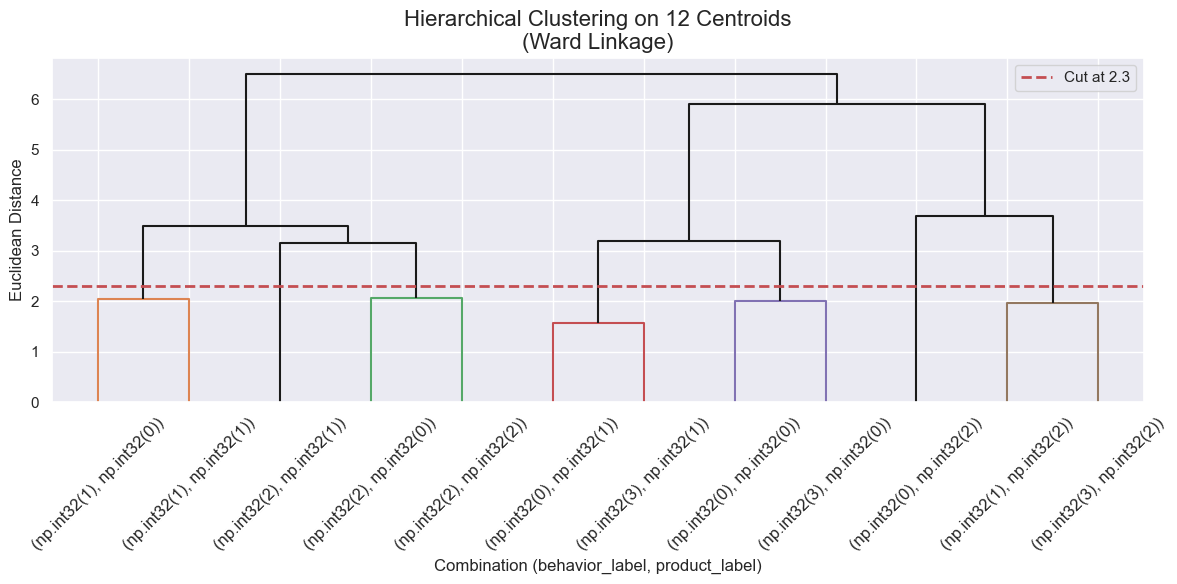

In [36]:
# Cell 18: Plot dendrogram with cutting options
fig = plt.figure(figsize=(12, 6))

# Potential cutting heights to consider
y_threshold = 2.3  # Can adjust this!

dendrogram(
    linkage_matrix,
    labels=df_centroids.index,
    color_threshold=y_threshold,
    above_threshold_color='k'
)

plt.axhline(y=y_threshold, color='r', linestyle='--', linewidth=2, label=f'Cut at {y_threshold}')

plt.title(f'Hierarchical Clustering on 12 Centroids\n(Ward Linkage)', fontsize=16)
plt.xlabel('Combination (behavior_label, product_label)')
plt.ylabel('Euclidean Distance')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
#para contar o numero de clusters so temos de contar o numero de linhas que temos por baixo da linha vermelha no dendrogram (linha horizontal)

#se mudarmos a line para 3.3 temos 5 clusters (y-treshold)

#na opiniao da stora 5 clusters é melhor que 7 mas isso é relativo com o probelma que estamos a tentar resolver e é uma decisão pessoal (do grupo)
#só temos de explicar pq queremos mais grupos (clusters) e qual o beneficio disso. O importante é msm a justificação 

#### Apply the HC with *n* clusters on the centroids 

In [38]:
#agora é que vamos msm aplicar a hierachical clustering 

In [39]:
# ===========================================================
# TODO IN CLASS EXERCISE
# Apply the final HC solution to the combined centroids 
# ===========================================================

n_final_clusters = 7

hclust_final = AgglomerativeClustering(
    linkage='ward',
    n_clusters=n_final_clusters
)

hclust_final_labels = hclust_final.fit_predict(df_centroids)
hclust_final_labels


array([2, 5, 3, 1, 1, 4, 0, 6, 0, 2, 5, 4])

In [40]:
# Add to centroids dataframe
df_centroids['merged_labels'] = hclust_final_labels
df_centroids

income       frq  per_net_purchase  \
demographic_cluster product_cluster                                         
0                   0               -0.940278 -0.866037          0.830908   
                    1               -0.619995 -0.883470          0.656130   
                    2               -1.335720 -0.917028          0.765915   
1                   0                1.225656  1.215908         -1.466062   
                    1                1.132018  1.211537         -1.293445   
                    2                1.192532  0.948318         -1.426911   
2                   0                0.922173  1.309060         -0.095808   
                    1                0.694561  1.132953          0.203993   
                    2                0.964308  1.148731         -0.242153   
3                   0                0.203412 -0.118484         -0.254265   
                    1                0.142217 -0.078979          0.090058   
                    2                0.220593 -0.237261         -0.351878   

                                     spent_online   clothes   kitchen  \
demographic_cluster product_cluster                                     
0                   0                   -0.788843 -0.466916 -0.046671   
                    1                   -0.762614  0.952275 -0.605554   
                    2                   -0.859748 -1.448441  1.545120   
1                   0                    0.287852 -0.476508 -0.060168   
                    1                    0.466873  0.736300 -0.524088   
                    2                    0.181326 -1.129984  1.297631   
2                   0                    2.051962 -0.220142 -0.025809   
                    1                    2.074392  1.096565 -0.600380   
                    2                    1.707176 -0.769771  1.089918   
3                   0                    0.047507 -0.254416 -0.036726   
                    1                    0.165298  1.052006 -0.576998   
                    2                   -0.070838 -0.892173  1.204312   

                                     small_appliances      toys  \
demographic_cluster product_cluster                               
0                   0                        0.905167 -0.029547   
                    1                       -0.694518 -0.611294   
                    2                       -0.012255  1.502286   
1                   0                        0.941329 -0.010804   
                    1                       -0.462424 -0.500623   
                    2                        0.188863  1.112619   
2                   0                        0.452455 -0.018896   
                    1                       -0.958456 -0.619645   
                    2                       -0.315350  0.921686   
3                   0                        0.460568  0.029415   
                    1                       -0.922951 -0.593394   
                    2                       -0.300017  1.182338   

                                     house_keeping  merged_labels  
demographic_cluster product_cluster                                
0                   0                    -0.013341              2  
                    1                    -0.601758              5  
                    2                     1.565495              3  
1                   0                    -0.050223              1  
                    1                    -0.503053              1  
                    2                     0.854516              4  
2                   0                    -0.038958              0  
                    1                    -0.598234              6  
                    2                     0.985089              0  
3                   0                     0.021307              2  
                    1                    -0.567726              5  
                    2                     0.975481              4

In [41]:
cluster_mapper = df_centroids['merged_labels'].to_dict()
cluster_mapper  

{(0, 0): 2,
 (0, 1): 5,
 (0, 2): 3,
 (1, 0): 1,
 (1, 1): 1,
 (1, 2): 4,
 (2, 0): 0,
 (2, 1): 6,
 (2, 2): 0,
 (3, 0): 2,
 (3, 1): 5,
 (3, 2): 4}

In [42]:
# Cell 21: Map merged labels back to all customers
df['merged_labels'] = df.apply(
    lambda row: cluster_mapper[(row['demographic_cluster'], row['product_cluster'])],
    axis=1
)
df


,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,...,oh_description_Kind of OK,oh_description_Meh...,oh_description_OK nice!,oh_description_Take my money!!,PC0,PC1,PC2,demographic_cluster,product_cluster,merged_labels
0,78,0.743162,1.191605,0.457819,1402,-0.617023,-0.243065,1.216847,0.495837,-0.499274,...,0.0,0.0,0.0,1.0,0.896356,-1.937697,1.120781,1,0,1
1,88,1.559488,1.100011,-1.535723,1537,0.166160,-0.790228,0.740464,-0.374374,-0.631907,...,0.0,0.0,0.0,1.0,1.981092,-1.421498,0.785625,1,0,1
2,34,-1.548542,-0.823463,0.557496,44,-0.834573,1.672006,-0.371096,-0.809480,2.286023,...,1.0,0.0,0.0,0.0,-2.813108,0.381440,-0.780867,0,2,3
3,69,0.845528,0.550447,-1.402820,888,0.383710,0.440889,-0.768082,-0.084304,-0.234007,...,0.0,0.0,1.0,0.0,1.247013,-0.514177,-1.302203,3,1,5
4,69,0.782435,1.008417,-0.871209,1138,0.340200,-0.243065,-0.053508,-0.374374,-0.366640,...,0.0,0.0,0.0,1.0,1.781920,-0.704805,-0.443376,2,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8812,70,0.618993,0.458853,-1.701851,837,0.209670,0.167308,-0.132905,0.205767,-0.764540,...,1.0,0.0,0.0,0.0,1.162525,-0.372854,-0.982963,2,0,0
8813,64,0.874744,0.733635,-1.701851,896,0.731791,-0.243065,-0.609288,-0.519409,-0.366640,...,0.0,0.0,0.0,1.0,2.003026,0.083121,-1.428619,2,1,6
8814,49,-0.455617,-0.731869,-1.535723,61,0.079139,-0.106274,-0.053508,0.060732,-0.101374,...,0.0,1.0,0.0,0.0,-1.002171,1.301747,-0.423851,0,0,2
8815,38,-0.596155,0.825229,0.657173,1011,-0.442982,0.577680,0.581670,-0.809480,0.561792,...,0.0,0.0,0.0,1.0,0.130573,-0.959962,0.332242,3,0,2


In [43]:
print(df['merged_labels'].value_counts().sort_index())

merged_labels
0     302
1    1641
2    2131
3    1022
4     495
5    2492
6     709
Name: count, dtype: int64


### Are the merged clusters balanced ? 

In [44]:
# Quick distinctiveness check (R²)
r2_merged = get_rsq(df, metric_features, 'merged_labels')
print(f"\nMerged clustering R²: {r2_merged:.4f}")


Merged clustering R²: 0.5938


##### How could you compare different final K merged solutions ? 

# Profiling 

In [45]:
# fizemos o msm para o kmeans e para o hoerarchical clusters, agora vamos fazer para o merged clusters

## Metric features 

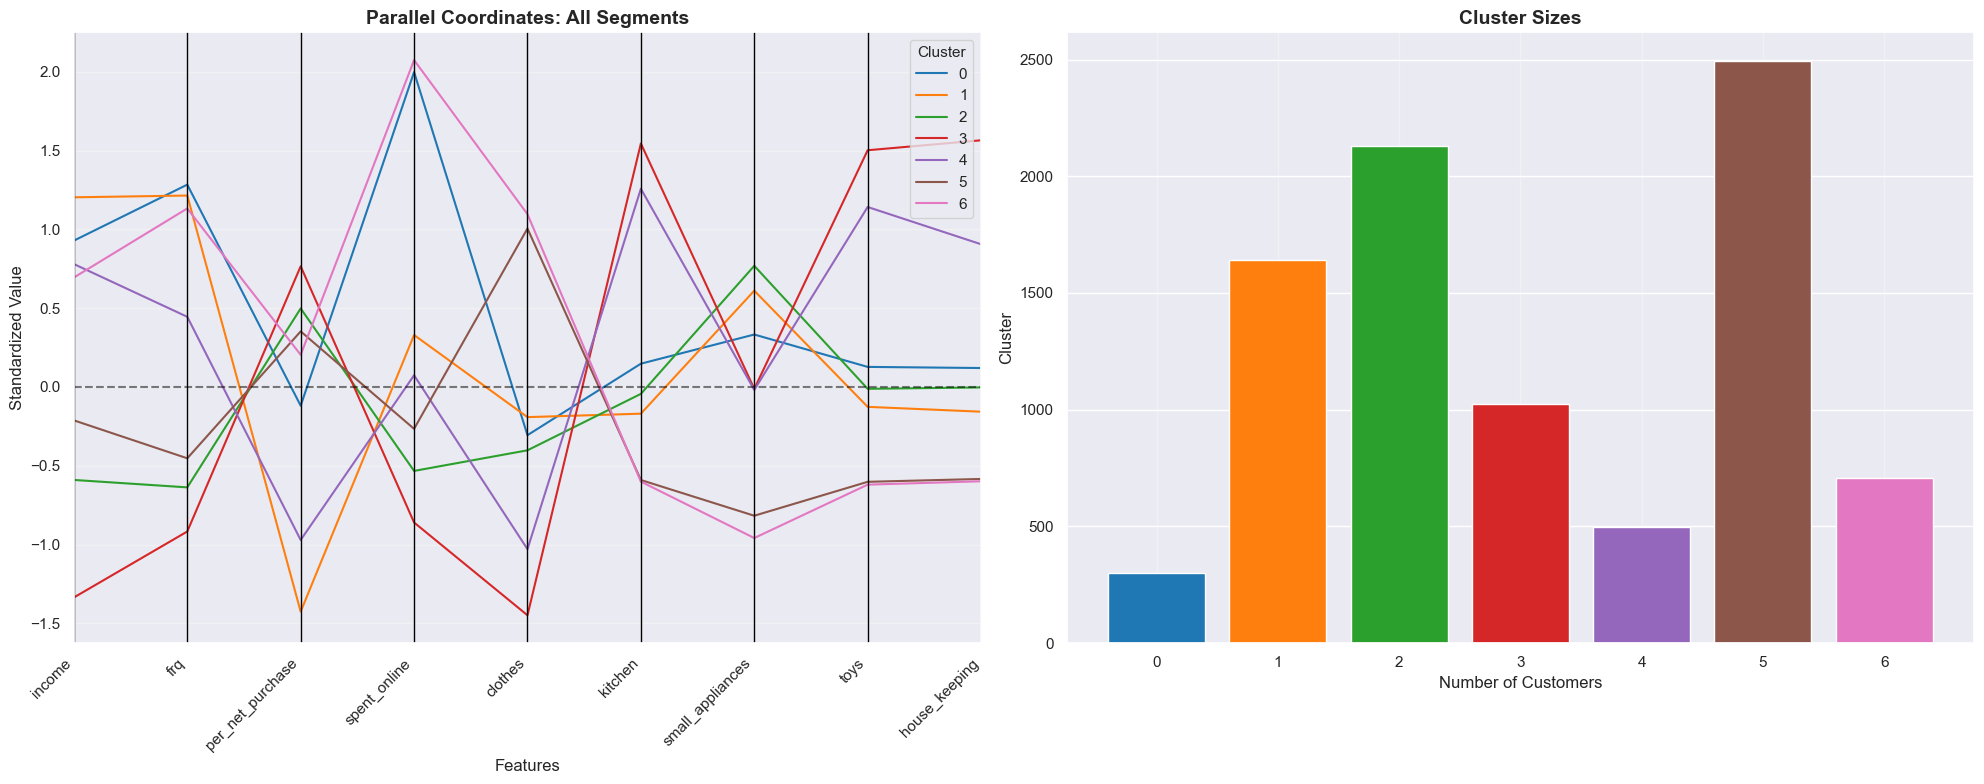

In [46]:
# Get centroids for ALL segments
all_segments = sorted(df['merged_labels'].unique())
df_all_centroids = df.groupby('merged_labels')[metric_features].mean()

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# LEFT PLOT: Parallel coordinates for all clusters
plt.sca(ax1)
pd.plotting.parallel_coordinates(
    df_all_centroids.reset_index(),
    'merged_labels',
    color=sns.color_palette('tab10', n_colors=len(all_segments)),
    ax=ax1
)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
ax1.set_title('Parallel Coordinates: All Segments', fontsize=14, fontweight='bold')
ax1.set_ylabel('Standardized Value', fontsize=12)
ax1.set_xlabel('Features', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.legend(title='Cluster', loc='best', title_fontsize=11)
ax1.grid(True, alpha=0.3)

# RIGHT PLOT: Cluster sizes (ordered by cluster number)
cluster_sizes = df['merged_labels'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=len(all_segments))

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
ax2.set_xlabel('Number of Customers', fontsize=12)
ax2.set_ylabel('Cluster', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

#### What other plot you can chose to profile the metric features ? 

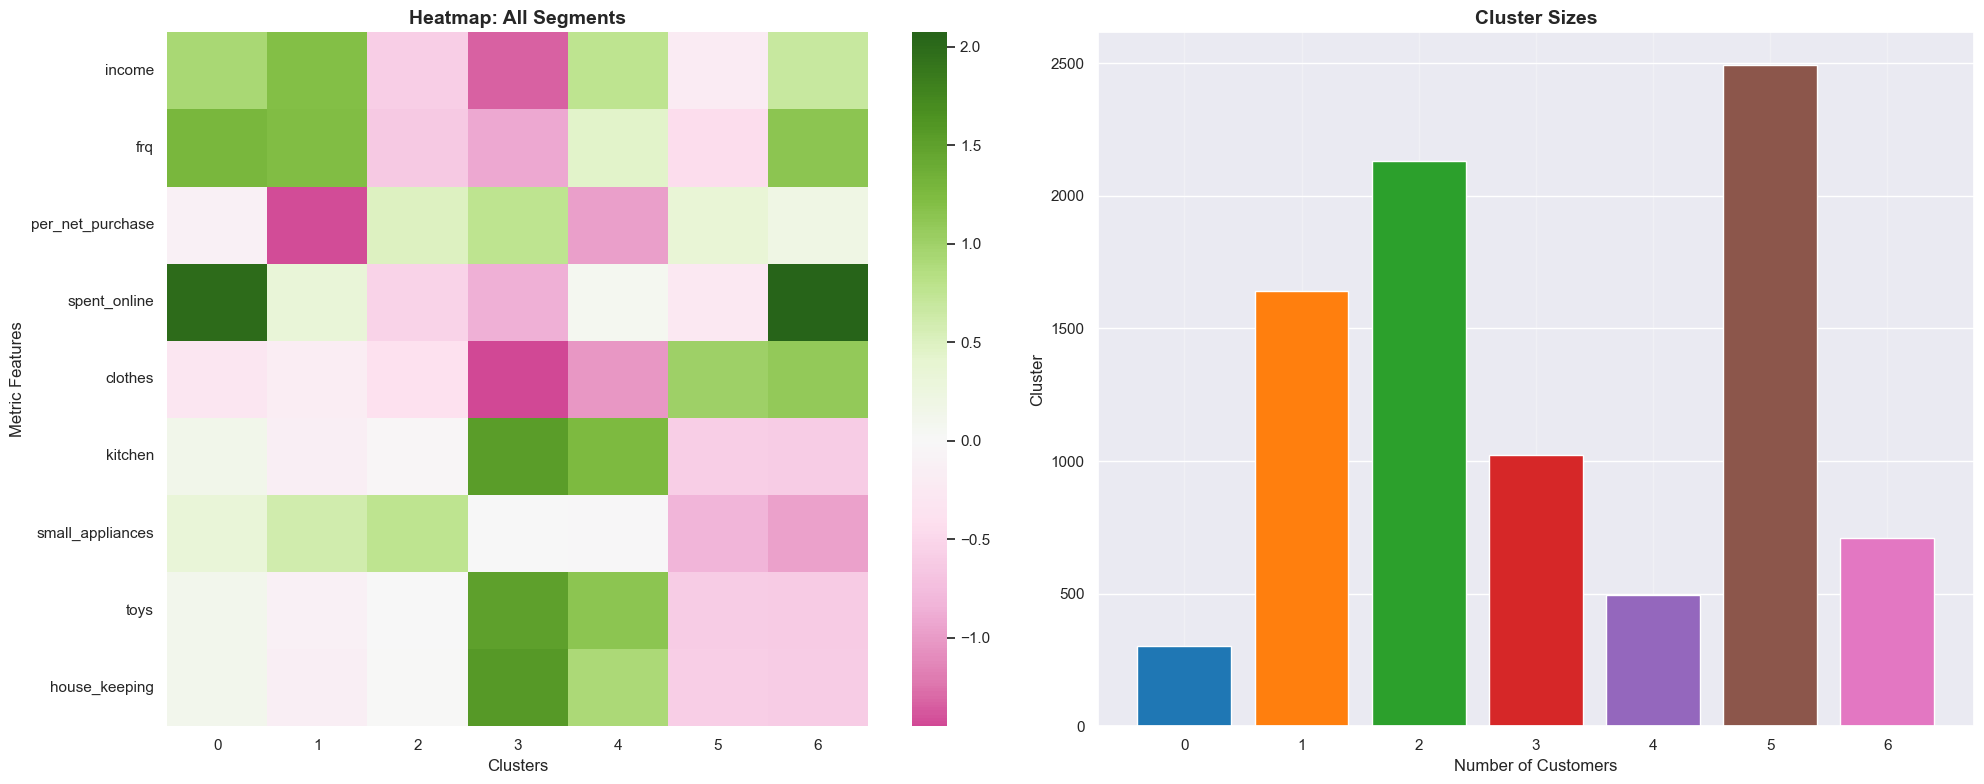

In [55]:
# ===========================================================
# TODO IN CLASS EXERCISE 
# Plot other type of visualization to profile the metric features
# ===========================================================

all_segments = sorted(df['merged_labels'].unique())
df_all_centroids = df.groupby('merged_labels')[metric_features].mean().T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    df_all_centroids,
    cmap='PiYG',
    ax=ax1,
    center=0
)

ax1.set_title('Heatmap: All Segments', fontsize=14, fontweight='bold')
ax1.set_ylabel('Metric Features', fontsize=12)
ax1.set_xlabel('Clusters', fontsize=12)
ax1.grid(False)


cluster_sizes = df['merged_labels'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=len(all_segments))

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
ax2.set_xlabel('Number of Customers', fontsize=12)
ax2.set_ylabel('Cluster', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
#vamos começar por analisar o 4ª e o 6ª clusters, pq nao conseguimaos ver o padrao de pessoas com alto income com pessoas que gastavam mais dinheiro em roupa. aqui já conseguimos ver este padrão
#
#analisar as relaçoes das diferentes features em cada cluster e perceber pq é que elas estao juntas naquele cluster, criar narrativas para cada cluster
#por exemplo no cliuster 4 a stora disse que podiamos considerar que eram as familias ricas :)

# dar "nomes" a cada cluster

## Non metric features 

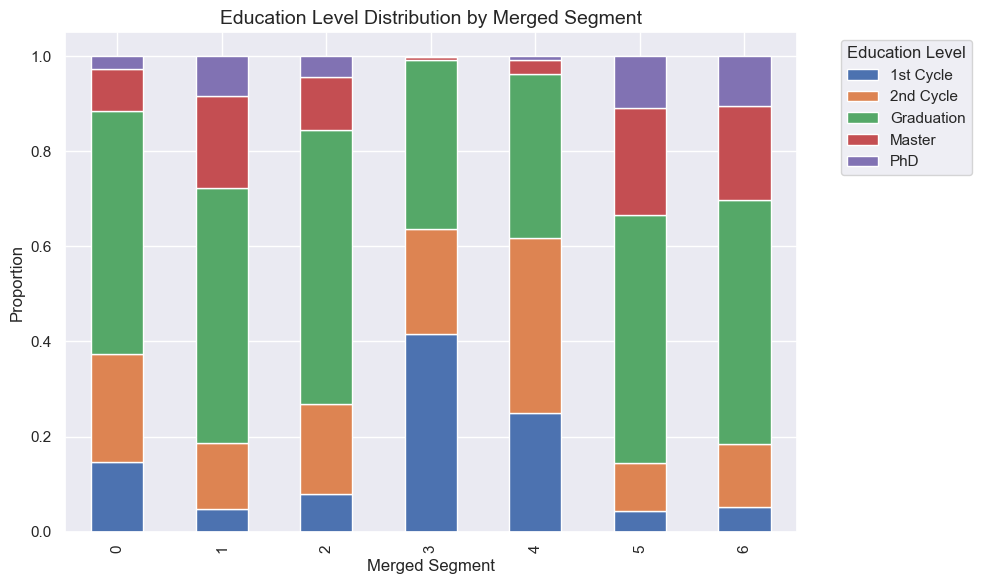

In [49]:
# ===========================================================
# TODO IN CLASS EXERCISE
# Improve the profiling visualization for education across segments
# ===========================================================

pd.crosstab(df['merged_labels'], df['education'], normalize='index').plot.bar(
    stacked=True,
    figsize=(10, 6)
)
plt.title("Education Level Distribution by Merged Segment", fontsize=14)
plt.xlabel("Merged Segment")
plt.ylabel("Proportion")
plt.legend(title="Education Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [50]:
# é difificl de ler em gráfico de barras e por isso fizemos um stacked bar chart, mudando stacked=True

# Feature Importances 

### Using $R^2$

Do you still remember the formula for $R^2$ calculation ? 

What proportion of each feature's total variance is explained by the cluster assignments?

In [51]:
def get_ss_variables(df):
    """Get the SS for each variable
    """
    ss_vars = df.var() * (df.count() - 1)
    return ss_vars

def r2_variables(df, labels):
    """Get the R² for each variable
    """
    sst_vars = get_ss_variables(df)
    ssw_vars = np.sum(df.groupby(labels).apply(get_ss_variables))
    return 1 - ssw_vars/sst_vars

In [52]:
r2_feats = r2_variables(df[metric_features + ['merged_labels']], 'merged_labels').drop('merged_labels')
#dropamos os merge labels mas nao queremos que eles aparecem na lista. Anyways eles entram no calculo do R2
r2_feats

/var/folders/s9/nfpy2jls4ps2k_p8lpjz6_yr0000gn/T/ipykernel_12803/364241649.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ssw_vars = np.sum(df.groupby(labels).apply(get_ss_variables))
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


income              0.678157
frq                 0.702309
per_net_purchase    0.600809
spent_online        0.685374
clothes             0.738427
kitchen             0.505233
small_appliances    0.479951
toys                0.477949
house_keeping       0.472459
dtype: float64

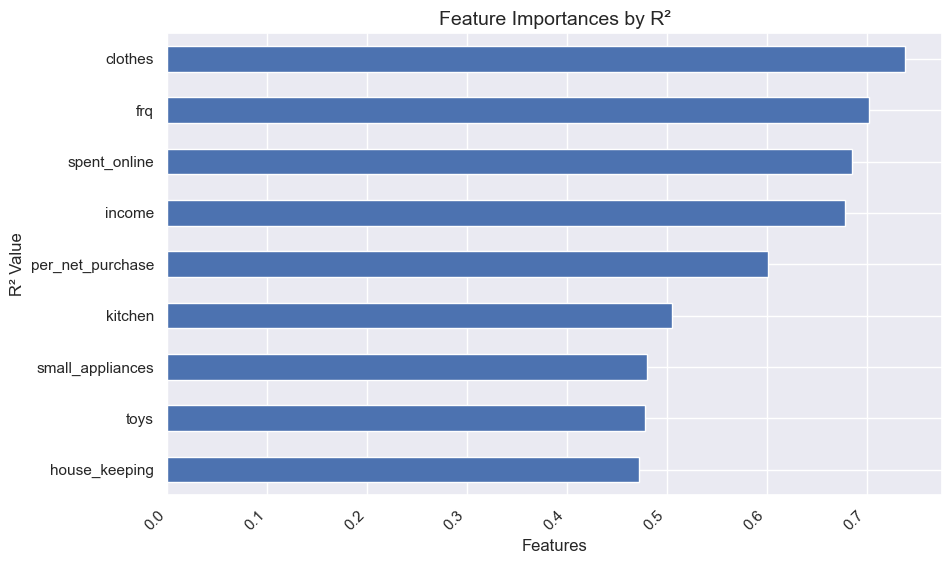

In [53]:
r2_feats.sort_values().plot.barh(figsize=(10,6))
plt.title("Feature Importances by R²", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("R² Value", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.show()

In [54]:
#clothes sao a feature mais importante, depois frq. e depois spent_online

#PARA O TRABALHO: A stora aconselha a fazer esta parte para features que tb nao tenhamos selecionado pq pode ter nos passado alguma feature importante

##### So what are the features that most differentiate the segments ? 

### Decision Tree Classifier 

- Train a Decision Tree Classifier model over the cluster labels
    - Estimate the respective feature importance (Gini importance)
    - Apply the trained model to classify multivariate outliers  

# Homework 
- Build a size-value matrix for the clusters 

- Apply two clustering perspectives to your project dataset (experiment several)